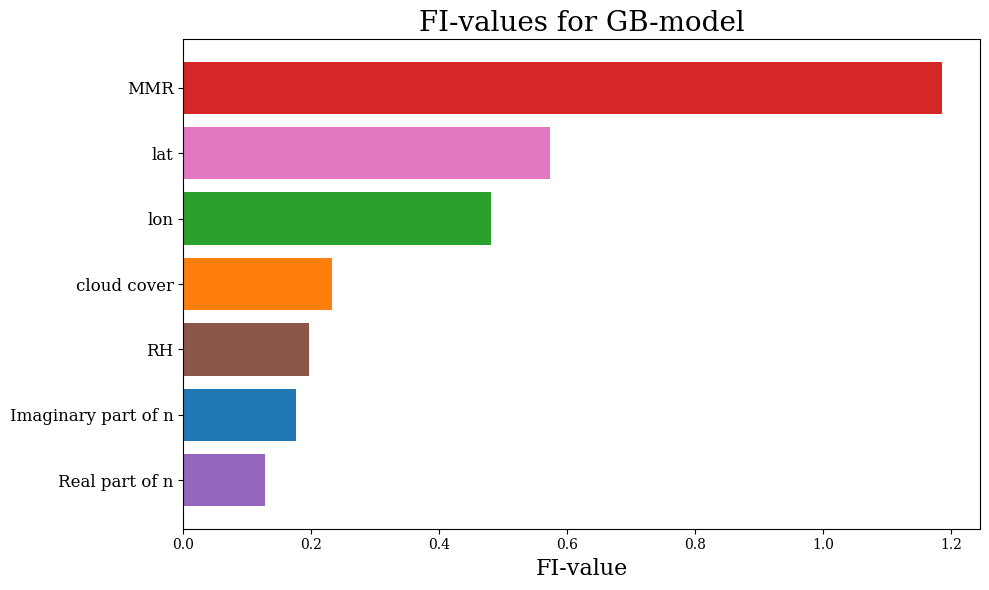

In [9]:
import numpy as np
import sys, os
import netCDF4 as nc
import matplotlib.pyplot as plt
import re
import pandas as pd
import seaborn as sns   

"""
by Atte Laakso / Aalto University

For plotting combined FI-values for domain-trained models into a barplot
"""
###################################################################################

# define parameters for this image
path = "../tools/FI_analysis/FI_results"
# models = ['GB','RF','DT','LR']
models = ['GB']
domain = '1'
dataset = 'dARE_ML_data_250721'
output_dir = "../tools/FI_analysis/FI_results"
###################################################################################

# load all model CSVs and txts
all_fi = []
weights = []

for model in models:
    folder = os.path.join(path, f'data={dataset}_multimodel=False_model={model}/')
    
    # load feature importances
    df = pd.read_csv(os.path.join(folder, 'feature_importances.csv'))
    
    # load model metrics from txt
    with open(os.path.join(folder, 'metrics.txt'), "r") as f:
        content = f.read()
        r2 = float(re.search(r"R2:\s*([0-9\.eE+-]+)", content).group(1))
        rmse = float(re.search(r"RMSE:\s*([0-9\.eE+-]+)", content).group(1))
    
    # define weight (R2 / RMSE as example)
    weight = r2 / rmse
    weights.append(weight)
    
    # store FI with weight
    df["weighted_importance"] = df["importance"] * weight
    all_fi.append(df[["feature", "weighted_importance"]])

# combine all results
combined = pd.concat(all_fi)

# aggregate and normalize
agg = combined.groupby("feature")["weighted_importance"].sum()
agg /= sum(weights)  # normalize by total weights

# function for creating the barplot
def foto(feature_names,importances):
    # map the actual names to features
    # name_map = {
    # "rh": r"$RH$",
    # "mmr": r"$x_\xi$",
    # "refrac": r"$n_r$",
    # "abs_coef": r"$n_i$",
    # "clt": r"$f_c$",
    # "row_idx":r"$j$",
    # "col_idx":r"$i$",
    # }
    name_map = {
    "rh": "RH",
    "mmr": "MMR",
    "refrac": "Real part of n",
    "abs_coef": "Imaginary part of n",
    "clt": "cloud cover",
    "row_idx":"lat",
    "col_idx":"lon",
    }
    
    real_names = [name_map.get(f, f) for f in feature_names]

    # consistent color per feature
    base_palette = sns.color_palette("tab10", len(name_map))  # or "Set2", "Paired", etc.
    color_map = dict(zip(real_names, base_palette))
    
    # create DataFrame with importances and their std deviation for easier handling
    feature_importances = pd.DataFrame({
        'feature': real_names,
        'importance': importances,
    }).sort_values(by='importance', ascending=False)
    
    # plot results and std as error bars
    plt.figure(figsize=(10, 6))
    # plt.rcParams["text.usetex"] = False           # make sure system latex isn't required
    # plt.rcParams["mathtext.fontset"] = "cm"       # Computer Modern
    # plt.rcParams["font.family"] = "serif"         # ensure serif base font
    plt.rcParams["ytick.labelsize"] = 12          # control y-axis tick (feature names) size
    plt.rcParams["xtick.labelsize"] = 10          # x-axis ticks too
    plt.barh(
        feature_importances["feature"],
        feature_importances["importance"],
        color=[color_map[f] for f in feature_importances["feature"]]
    )
    plt.xlabel("FI-value", fontsize=16)
    # plt.title(f"Weighted Average of FI-values Using All Data -Models", fontsize=20)
    plt.title(f"FI-values for GB-model", fontsize=20)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    # plt.savefig(os.path.join(output_dir, f"feature_importances_plot_weighted_avg.png"))
    plt.savefig(os.path.join(output_dir, f"all_FI_barplot_GB.png"))
    plt.show()
    plt.close()
    return

# make the plots for all the models
foto(agg.index, agg.values)